In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import svm
import pandas as pd

In [2]:
df =pd.read_csv("data/svm_data.csv")

In [3]:
df.head()

,voltage_v,bias_voltage_v,Target
0,6.377345,-10.615107,1
1,6.500727,-3.824036,0
2,4.292259,-8.992204,1
3,7.391695,-3.126693,0
4,7.643063,-10.023569,1


In [20]:
x=df[['voltage_v','bias_voltage_v']]
y=df[['Target']]

In [21]:
x.iloc[:,0]

0      6.377345
1      6.500727
2      4.292259
3      7.391695
4      7.643063
5      8.681857
6      5.370422
7      9.242238
8      5.730058
9      7.968331
10     7.375784
11     6.952924
12     8.212012
13     6.850868
14     5.644430
15    10.488484
16     7.270590
17     6.297846
18     9.421693
19     8.984267
20     6.600873
21     5.953136
22     6.871511
23     6.262215
24     7.971644
25     7.676196
26     7.927368
27     5.863112
28     8.075024
29     6.783353
30     7.893600
31     6.049078
32     6.778113
33     8.714451
34     8.491428
35     9.496494
36     7.521321
37     6.388393
38     7.933331
39     6.868665
Name: voltage_v, dtype: float64

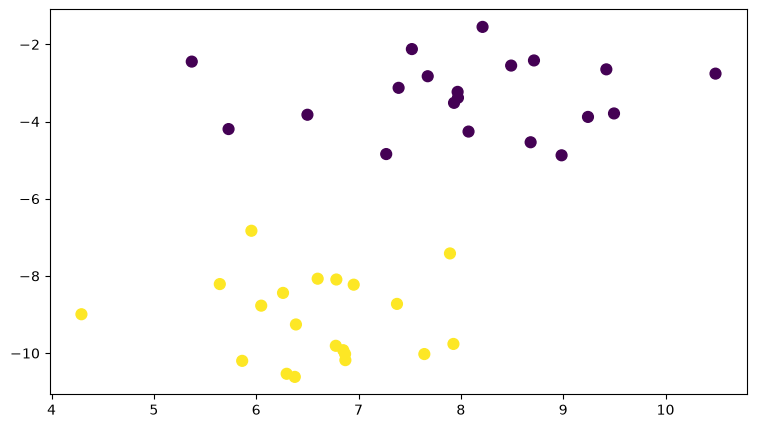

In [26]:
plt.figure(figsize=(9,5))
plt.scatter(x.iloc[:,0],x.iloc[:,1],c=df['Target'],s=60)

In [17]:
clf=svm.SVC(kernel='linear')
clf.fit(x,y)


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [28]:
w=clf.coef_
b=clf.intercept_
print(w)
print(b)
alphas=np.abs(clf.dual_coef_[0])
print(alphas)

[[-0.2539717  -0.83806387]]
[-3.21132826]
[0.38347857 0.25400249 0.12947608]


In [29]:
support_vectors = clf.support_vectors_
alphas = np.abs(clf.dual_coef_[0])
alphas

array([0.38347857, 0.25400249, 0.12947608])

d:\DEPI\CA-AI-DEPI\.venv-Depi\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


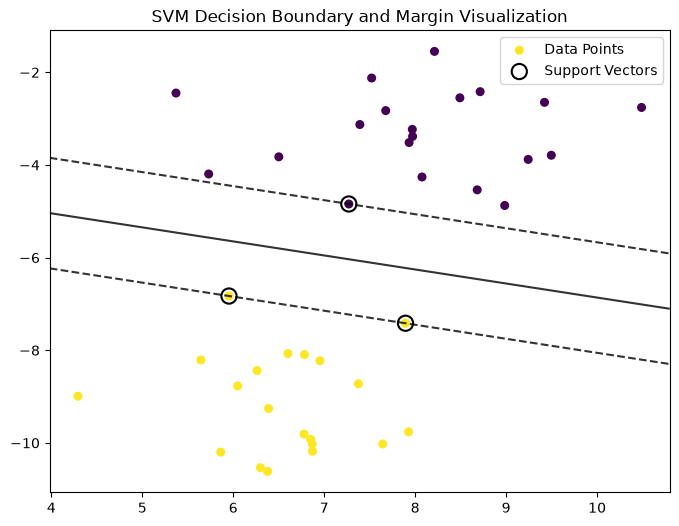

In [35]:
 
plt.figure(figsize=(8, 6))
plt.scatter(
    x.iloc[:,0],x.iloc[:,1], c=df['Target'], s=30, label="Data Points"
)
 
plt.scatter(
    support_vectors[:, 0],
    support_vectors[:, 1],
    s=120,
    facecolors="none",
    edgecolors="k",
    linewidths=1.5,
    label="Support Vectors",
)
 
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()
 
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = clf.decision_function(xy).reshape(XX.shape)
 
ax.contour(
    XX,
    YY,
    Z,
    colors="k",
    levels=[-1, 0, 1],
    alpha=0.8,
    linestyles=["--", "-", "--"],
)
 
plt.title("SVM Decision Boundary and Margin Visualization")
plt.legend()
plt.show()
 